In [4]:
# Install required packages
# pip install -q pandas scikit-learn==1.2.2 numpy xgboost

# Import libraries
import pandas as pd
import numpy as np
import os
import shutil
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from typing import Tuple, Optional
import sys
from lifelines import WeibullAFTFitter
import os 

sys.path.append('../../utilities')

from preprocess import preprocess

In [5]:
# Define path to the single participant data folder.
PARTICIPANT_DATA_PATH = '/home/dgxuser40/manjil/finsurv/participant_data'

In [6]:
index_event = 'Borrow'
outcome_event = 'Deposit'

In [7]:
dataset_path = os.path.join(index_event, outcome_event)
train_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'train.csv'))
test_features_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'test_features.csv'))

In [8]:
X_train, y_train, X_test_processed = preprocess(train_df, test_features_df)

In [9]:
X_train.head()

,userBorrowSum,marketWithdrawAvgAmount,marketDepositAvgAmountUSD,sinDayOfMonth,userSecondsSinceFirstTransaction,timeOfDay,userActiveDaysWeekly,userLiquidationCount,userActiveDaysMonthly,userRepayCount,...,sinDayOfWeek,userBorrowAvgAmountUSD,userSecondsSincePreviousTransaction,marketBorrowSumUSD,userRepaySum,logAmountUSD,marketDepositCount,marketRepayAvgAmountUSD,sinQuarter,marketLiquidationAvgAmount
0,-0.399386,-2.485869,-2.098349,-0.30633,-0.798238,-0.544429,-1.192513,-0.156479,-1.073938,-0.403717,...,0.55663,-0.486278,-0.131531,-1.733398,-0.399299,-1.382277,-1.577102,-2.370332,1.544713,-0.932578
1,-0.399386,-2.485869,-2.094074,-0.30633,-0.798467,-0.052154,-1.192513,-0.156479,-1.073938,-0.403717,...,0.55663,-0.486259,-0.133963,-1.733398,-0.399299,-1.281106,-1.577028,-2.370332,1.544713,-0.932578
2,-0.399386,-2.486612,-1.485896,-0.30633,-0.798475,0.022138,-1.192513,-0.156479,-1.073938,-0.403717,...,0.55663,-0.486252,-0.134041,-1.733398,-0.399299,-1.253623,-1.576732,-2.370332,1.544713,-0.932578
3,-0.399386,-1.755712,-1.551480,-0.30633,-0.797823,0.073279,-1.192513,-0.156479,-1.073938,-0.403717,...,0.55663,-0.486089,-0.133956,-1.733398,-0.399299,-0.770533,-1.576547,-2.361107,1.544713,-0.932578
4,-0.399386,-1.755712,-1.598705,-0.30633,-0.798483,0.089520,-1.192513,-0.156479,-1.073938,-0.403717,...,0.55663,-0.484555,-0.134123,-1.733397,-0.399299,-0.414304,-1.576454,-2.361107,1.544713,-0.932578


In [10]:
y_train_xgb = np.where(
            y_train['status'] == 1,
            y_train['timeDiff'],  # positive for events
            -y_train['timeDiff']  # negative for censored
        )
        
# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train_xgb)
dtest = xgb.DMatrix(X_test_processed)
        
# XGBoost parameters for survival analysis
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'max_depth': 3,
    'eta': 0.1,  # learning rate
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'lambda': 1.0,  # L2 regularization
    'alpha': 0.0,   # L1 regularization
    'seed': 42
}
        
print(f"Training XGBoost survival:cox model for {dataset_path}...")
model = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    verbose_eval=False
)
print("  - Model trained successfully.")

# --- Generate and Save Predictions ---
print(f"Generating predictions for {dataset_path}...")
# Predict risk scores (higher score = higher risk)
predictions = -model.predict(dtest)

Training XGBoost survival:cox model for Borrow/Deposit...
  - Model trained successfully.
Generating predictions for Borrow/Deposit...


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

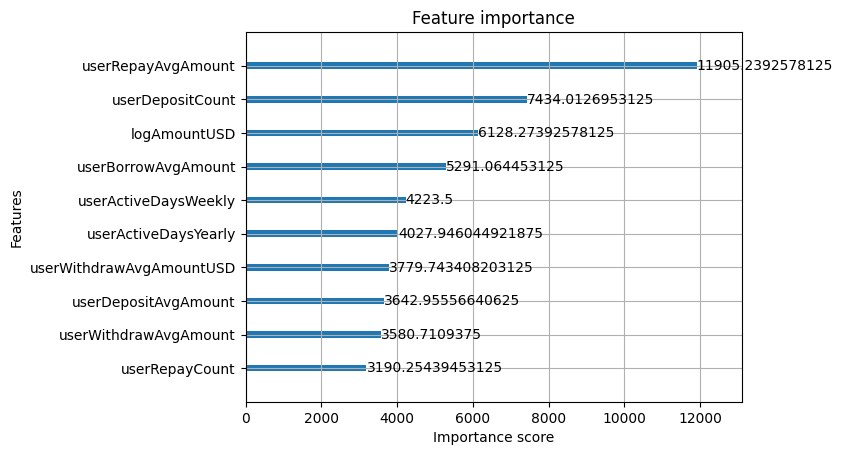

In [11]:
xgb.plot_importance(model, importance_type='gain', max_num_features=10)

In [12]:
# get feature importance scores (by weight, gain, or cover)
importance = model.get_score(importance_type='gain')  # 'weight', 'gain', 'cover'
# sort by importance (highest to lowest)
sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
top_n = 100
top_features = sorted_features[:top_n]
print("Top Features:")
# for feature, score in top_features:
#     print(f"{feature}: {score:.4f}")
top_features

Top Features:


[('userRepayAvgAmount', 11905.2392578125),
 ('userDepositCount', 7434.0126953125),
 ('logAmountUSD', 6128.27392578125),
 ('userBorrowAvgAmount', 5291.064453125),
 ('userActiveDaysWeekly', 4223.5),
 ('userActiveDaysYearly', 4027.946044921875),
 ('userWithdrawAvgAmountUSD', 3779.743408203125),
 ('userDepositAvgAmount', 3642.95556640625),
 ('userWithdrawAvgAmount', 3580.7109375),
 ('userRepayCount', 3190.25439453125),
 ('marketWithdrawAvgAmountUSD', 3074.239501953125),
 ('userDepositSum', 2973.848876953125),
 ('marketRepayAvgAmountUSD', 2952.38232421875),
 ('userBorrowCount', 2716.05029296875),
 ('userDepositSumUSD', 2319.461669921875),
 ('marketBorrowSumUSD', 2115.73681640625),
 ('userLiquidationSumUSD', 2059.29736328125),
 ('userWithdrawSumUSD', 2032.2615966796875),
 ('dayOfYear', 1969.278076171875),
 ('userRepaySumUSD', 1955.236328125),
 ('userWithdrawCount', 1933.995361328125),
 ('userDepositAvgAmountUSD', 1894.22705078125),
 ('userLiquidationCount', 1824.3814697265625),
 ('userRepayA

In [29]:
top_n = [feature for feature, score in top_features]
top_n

['userRepayAvgAmount',
 'userDepositCount',
 'logAmountUSD',
 'userBorrowAvgAmount',
 'userActiveDaysWeekly',
 'userActiveDaysYearly',
 'userWithdrawAvgAmountUSD',
 'userDepositAvgAmount',
 'userWithdrawAvgAmount',
 'userRepayCount',
 'marketWithdrawAvgAmountUSD',
 'userDepositSum',
 'marketRepayAvgAmountUSD',
 'userBorrowCount',
 'userDepositSumUSD',
 'marketBorrowSumUSD',
 'userLiquidationSumUSD',
 'userWithdrawSumUSD',
 'dayOfYear',
 'userRepaySumUSD',
 'userWithdrawCount',
 'userDepositAvgAmountUSD',
 'userLiquidationCount',
 'userRepayAvgAmountUSD',
 'userBorrowAvgAmountUSD',
 'priceInUSD',
 'userWithdrawSum',
 'userLiquidationAvgAmount',
 'cosDayOfYear',
 'marketRepayCount',
 'userSecondsSinceFirstTransaction',
 'userLiquidationAvgAmountUSD',
 'marketWithdrawCount',
 'userSecondsSincePreviousTransaction',
 'amountUSD',
 'userBorrowSum',
 'userBorrowSumUSD',
 'sinDayOfYear',
 'dayOfMonth',
 'marketDepositAvgAmount',
 'marketDepositCount',
 'marketWithdrawSumUSD',
 'marketRepaySum'